## About

In this notebook we will be exploring the following [dataset](https://www.kaggle.com/datasets/chebotinaa/fast-food-marketing-campaign-ab-test?select=WA_Marketing-Campaign.csv) from kaggle.

**Scenario:**
A fast-food chain plans to add a new item to its menu. However, they are still undecided between three possible marketing campaigns for promoting the new product. In order to determine which promotion has the greatest effect on sales, the new item is introduced at locations in several randomly selected markets. A different promotion is used at each location, and the weekly sales of the new item are recorded for the first four weeks. 
The relevant information is included in the dataset, which we'll explore.

**Goal:**
Evaluate A/B testing results and decide which marketing strategy works the best.

**Target Metric:**
Average weekly sales per location

This metric lets us evaluate the performance of each store corresponding to the promotion/ marketing strategy used. 
From there we can look at trends over time and based on which promotion increases the sales the most, we can choose the best working marketing strategy. 

Therefore:
The most effective promotion is the one that achieves the highest average weekly sales per location, consistently across the observed period.

## Load the dataset and Overview of the dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
import scipy.stats as stats
import shutil
from itertools import combinations

In [2]:
from consts import FAST_FOOD_MARKETING_DATASET

We use a copy of our dataset to leave the original one untouched.

In [3]:
shutil.copy(FAST_FOOD_MARKETING_DATASET, "Datasets/WA_Marketing-Campaign_copy.csv")
marketing_data = pd.read_csv("Datasets/WA_Marketing-Campaign_copy.csv")

In [4]:
marketing_data.head()

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


In [5]:
marketing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MarketID          548 non-null    int64  
 1   MarketSize        548 non-null    object 
 2   LocationID        548 non-null    int64  
 3   AgeOfStore        548 non-null    int64  
 4   Promotion         548 non-null    int64  
 5   week              548 non-null    int64  
 6   SalesInThousands  548 non-null    float64
dtypes: float64(1), int64(5), object(1)
memory usage: 30.1+ KB


We can see that we have 547 rows and 7 columns.
The datatypes are fine as well and we specifically observe the following columns: 'MarketID', 'MarketSize', 'LocationID', 'AgeOfStore', 'Promotion', 'week', 'SalesInThousands'.

## Data Cleaning

Checking for missing values:

In [6]:
marketing_data.isna().mean() * 100

MarketID            0.0
MarketSize          0.0
LocationID          0.0
AgeOfStore          0.0
Promotion           0.0
week                0.0
SalesInThousands    0.0
dtype: float64

We see that no values are missing.

Now let's check for duplicate rows and columns:

In [7]:
print(marketing_data.duplicated().any())

marketing_data_t = marketing_data.T
print(marketing_data_t.duplicated().any())

False
False


No duplicate rows and columns detected.

## Calculations

Aggregating and preparing data as needed. Reporting key information about the A/B test, including the sample size and variant proportions.

### Key information about the A/B test:

We start with our sample size - the number of unique locations:

In [8]:
print(f"sample size: {marketing_data['LocationID'].nunique()}")

sample size: 137


Now we take a look at the variant proportions differentiating between the three promotions: 

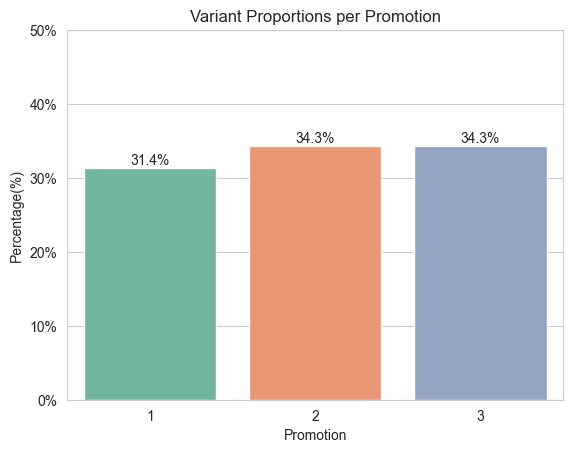

In [9]:
variant_proportions = marketing_data["Promotion"].value_counts(normalize=True)

sns.set_style("whitegrid")
colors = sns.color_palette("Set2", n_colors=3)

ax = sns.barplot(
    x=variant_proportions.index,
    y=variant_proportions.values,
    legend=False,
    hue=variant_proportions.index,
    palette=colors,
)
for container in ax.containers:
    ax.bar_label(
        container, labels=[f"{v*100:.1f}%" for v in container.datavalues], fontsize=10
    )
plt.title("Variant Proportions per Promotion")
plt.ylabel("Percentage(%)")
plt.xlabel("Promotion")
plt.ylim(0, 0.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.0f}%"))

plt.show()

We see that the dataset is quite balanced between the promotions, with variant proportions: promotion 1 ~31%, promotion 2 ~34% and promotion 3 ~34%.

Although we notice that the number of samples in each variant is not exactly the same. Some discrepancy should be expected due to randomness, but large differences, when they are not expected, are a symptom of a bug in the way units were randomized. This is known as sample ratio mismatch (SRM). Before we proceed with the analysis of the test, we test for the sample ratio mismatch using the chi-square test.

**Chi-square test:**

Nullhypothesis: The promotions have equal assignment ratios - no sample ratio mismatch (SRM) 

Alternative Hypothesis: The rate of the promotions differ - we have a SRM

Significance level: 0.05

We will now calculate the p-value and chi2 stats.

In [10]:
counts = marketing_data["Promotion"].value_counts()
statistic, p_value = stats.chisquare(f_obs=counts.values)
print(f"chi2 statistic: {statistic:.2f}")
print(f"p value: {p_value:.2f}")

chi2 statistic: 0.93
p value: 0.63


We see that the p value ~ 0.63 >= 0.05 (our significance level). We therefore fail to reject our Nullhypothesis, which means that we observe no SRM. The randomization is fine, the promotions have equal assignment ratios.

**Aggregating and preparing data as needed:**

Now let's prepare our dataset and calculate our **target metric**: the average weekly sales per location.

In [11]:
avg_sales = (
    marketing_data.groupby(["LocationID", "Promotion"])["SalesInThousands"]
    .describe()
    .rename(columns={"mean": "AvgWeeklySales"})
    .reset_index()
)

avg_sales.head()

,LocationID,Promotion,count,AvgWeeklySales,std,min,25%,50%,75%,max
0,1,3,4.0,34.4200,4.259092,29.03,32.5550,34.700,36.5650,39.25
1,2,2,4.0,29.5450,3.418367,27.72,27.7875,27.895,29.6525,34.67
2,3,1,4.0,40.6800,5.186784,34.75,37.1425,41.240,44.7775,45.49
3,4,2,4.0,33.7075,7.199293,24.77,29.4275,35.130,39.4100,39.80
4,5,2,4.0,29.0025,6.403454,23.35,24.4525,27.595,32.1450,37.47


Now we compare this metric **across our promotions**.

In [12]:
avg_sales_promotion = (
    avg_sales.groupby("Promotion")["AvgWeeklySales"]
    .describe()
    .rename(
        columns={"count": "locationCount", "mean": "AvgWeeklySalesMeanPerPromotion"}
    )
    .reset_index()
)
avg_sales_promotion

,Promotion,locationCount,AvgWeeklySalesMeanPerPromotion,std,min,25%,50%,75%,max
0,1,43.0,58.099012,16.028223,37.785,48.69625,56.0750,61.32500,95.0900
1,2,47.0,47.329415,14.497097,27.840,37.43375,46.6550,49.94375,83.1575
2,3,47.0,55.364468,16.383866,31.185,45.36750,49.8525,60.24500,88.5775


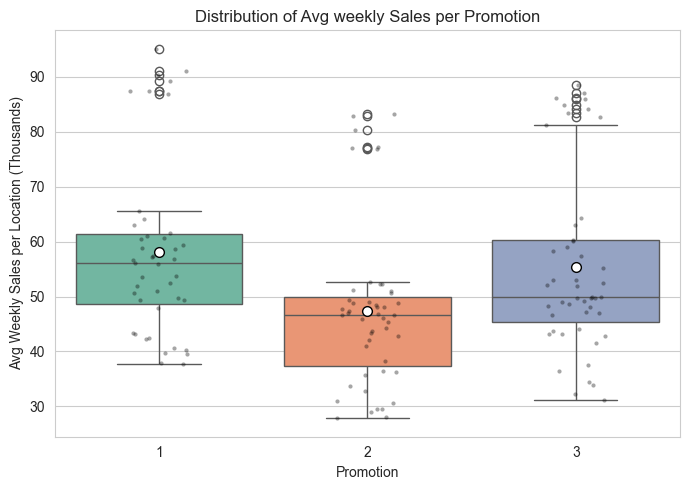

In [13]:
sns.set_style("whitegrid")
colors = sns.color_palette("Set2", n_colors=3)

plt.figure(figsize=(7, 5))
ax = sns.boxplot(
    data=avg_sales,
    x="Promotion",
    y="AvgWeeklySales",
    palette=colors,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 7,
    },
    hue="Promotion",
    legend=False,
)

sns.stripplot(
    data=avg_sales,
    x="Promotion",
    y="AvgWeeklySales",
    color="black",
    alpha=0.35,
    size=3,
    jitter=0.15,
)
ax.set_xlabel("Promotion")
ax.set_ylabel("Avg Weekly Sales per Location (Thousands)")
ax.set_title("Distribution of Avg weekly Sales per Promotion")
plt.tight_layout()
plt.show()

We see that Promotion 1 has the highest Avg weekly Sales Mean (~58T) and the highest Maximum Avg weekly Sales value with ~95T as well as ~10 outliers all around the 90T mark. 

Promotion 2 leads to the lowest AvgWeeklySalesMean (~47T) and also yields the lowest Min - global Minimum with ~27T, we indeed observe outliers mainly spreaded around the 80T mark with the Max ~83, which is the lowest Max out of the three promotions.

Although Promotion 3 has the middle AvgWeeklySalesMean (~55T) its 
upper edge of the whisker is around ~81T and we observe ~10-15 outlier values between the 80-90T mark.

Based on this data, Promotion 1 seems to be the best strategy. 

Now we want to see how Average Weekly Sales **evolve over Time** filtered by Promotion to examine possible trends and evaluate the performances well-balanced.

In [14]:
weekly_avg_sales = (
    marketing_data.groupby(["Promotion", "week"])["SalesInThousands"]
    .mean()
    .reset_index()
    .rename(columns={"SalesInThousands": "AvgSalesPerPromotionPerWeek"})
)
weekly_avg_sales.head()

,Promotion,week,AvgSalesPerPromotionPerWeek
0,1,1,58.244419
1,1,2,56.929535
2,1,3,58.774884
3,1,4,58.447209
4,2,1,47.730213


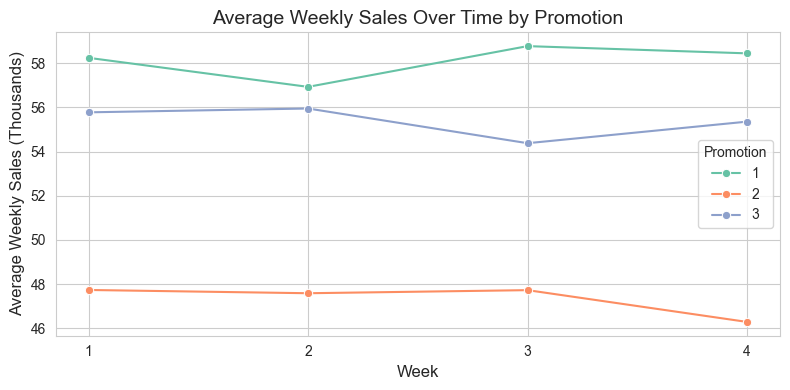

In [15]:
plt.figure(figsize=(8, 4))
colors = sns.color_palette("Set2", n_colors=3)

sns.lineplot(
    data=weekly_avg_sales,
    x="week",
    y="AvgSalesPerPromotionPerWeek",
    hue="Promotion",
    marker="o",
    palette=colors,
)

plt.title("Average Weekly Sales Over Time by Promotion", fontsize=14)
plt.ylabel("Average Weekly Sales (Thousands)", fontsize=12)
plt.xlabel("Week", fontsize=12)
plt.legend(title="Promotion")
plt.grid(True)
plt.xticks(sorted(weekly_avg_sales["week"].unique()))

plt.tight_layout()
plt.show()

We observe that Promotion 1 consistently performs best with the highest Average Weekly Sales ~58T, followed by Promotion 3 ~56T. Promotion 2 performs worst with Average weekly Sales around 46-48T.

**Key information about the A/B test - Summary:**

- Sample Size - Number of locations: 137; each of those locations is assigned to one of three Promotions
- Variant Proportions: Promotion 1: 31.4%, Promotion 2: 34.3%, Promotion 3: 34.3% -> no SRM; including additional verification through Chi2 test
- Aggregation and Data Preparation:
  - Target Metric: Average weekly sales per location
  - Concerning the Metric we observed: Avg Weekly Sales Mean Per Promotion comparison - Promotion-Level Overview, Avg weekly Sales over Time - Trends

**->** Promotion 1 seems to be the best; with the highest Mean on Avg weekly Sales per location and the best performance over time. 
   Followed by Promotion 3; and the worst Promotion 2.

### Are the differences statistically significant?

**Conduct statistical tests.** 

We will now continue with conducting statistical tests to check whether the observed differences in performance are statistically significant. - Do the average weekly sales per location differ significantly between promotions? And is promotion 1 really statistically significantly outperforming promotion 2 and 3?

First we form our groups, which are the Avg Weekly Sales per location differentiating by Promotion 1-3.

In [16]:
groups = {
    p: avg_sales.loc[avg_sales["Promotion"] == p, "AvgWeeklySales"].to_numpy()
    for p in sorted(avg_sales["Promotion"].unique())
}
X = list(groups.values())

We start with the Levene’s Test to check whether the variance across the groups are equal to choose the test to continue the statistical significance analysis.

**Levene's Test:**

Nullhypothesis: All group variances are equal. 

Alternative Hypothesis: At least one differs in variance.

Significance level: 0.05

We will now calculate the p-value and the Levene statistic.

In [17]:
levene_stat, levene_p = stats.levene(*X, center="median")
print(f"Levene stat: {levene_stat:.2f}\np value: {levene_p:.2f}")

Levene stat: 0.47
p value: 0.63


We see that the p value: 0.63 >= 0.05 - our significance level; which means that we fail to reject the Nullhypothesis, which means that the differences in variance across groups is'nt statistically significant.

We can now continue with the ANOVA test and pairwise t-tests, cause we can assume equal variances - needed for the tests.

**ANOVA Test:**

Nullhypothesis: The means of the groups are equal. 

Alternative Hypothesis: At least one differs.

Significance level: 0.05

We will now calculate the p-value and the ANOVA F value - the Between Group Var/ Within Group Var.

In [18]:
anova_stat, anova_p = stats.f_oneway(*X)
print(f"ANOVA F: {anova_stat:.2f}\np value: {anova_p:.4f}")

ANOVA F: 5.85
p value: 0.0037


We examine ANOVA F: 5.85 and p: 0.0037 < 0.05 - significance level; we therefore reject the Nullhypothesis and conclude that at least one promotion has a statistically significantly different Mean for the Avg weekly sales per location. In other words, the group means are not statistically equal.

We saw the exact mean differences earlier when we took a look at AvgWeeklySalesMeanPerPromotion, you can see that in the boxplot as well.

**This means:**

Concerning the observed differences of the Promotions in the Calculations part:
The observed superior performance of Promotion 1 is unlikely to be due to chance, the difference of those means is statistically relevant. Promotions 2 and 3 have lower means, with Promotion 2 performing the worst.

**But:**

To draw a conclusion of what promotion strategy is the best, we also need to consider exactly which promotions differ and by how much. 

We have to confirm the superior performance of Promotion 1 statistically.

This is why we are doing the pairwise t-tests now.

**Students T-Test:**

Pairwise:

Nullhypothesis: The difference in mean average weekly sales between the two promotions is 0. - no difference between performance of promotions.

Alternative Hypothesis: The difference of the means of the promotions are non-zero. - one performns better or worse than the other.

Significance level: 0.05

We will now calculate the p-values to determine which pairs show statistically significant differences.
We also want to know how much better one promotion performs than another - to have a tangible result.
We therefore compute the estimated treatment effect pairwise, including its confidence intervals.

In [19]:
pairs = list(combinations(sorted(groups.keys()), 2))

results = []
for p1, p2 in pairs:
    a, b = groups[p1], groups[p2]
    t_stat, p_val = stats.ttest_ind(a, b, equal_var=True)
    estimated_tr_effect = a.mean() - b.mean()

    n1, n2 = len(a), len(b)
    s1, s2 = a.var(ddof=1), b.var(ddof=1)
    s_p = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
    se = s_p * np.sqrt(1 / n1 + 1 / n2)
    df = n1 + n2 - 2
    ci_low, ci_high = stats.t.interval(0.95, df, loc=estimated_tr_effect, scale=se)

    results.append(
        {
            "pair": (int(p1), int(p2)),
            "t_stat": round(float(t_stat), 2),
            "p_value": round(float(p_val), 3),
            "estimated_tr_effect": round(float(estimated_tr_effect), 2),
            "ci_95_low": round(float(ci_low), 2),
            "ci_95_high": round(float(ci_high), 2),
        }
    )

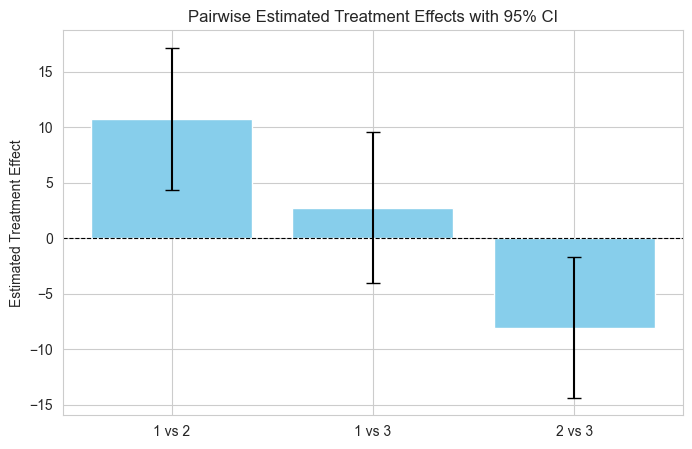

In [20]:
df = pd.DataFrame(results)

x = range(len(df))

plt.figure(figsize=(8, 5))
plt.bar(
    x,
    df["estimated_tr_effect"],
    yerr=[
        df["estimated_tr_effect"] - df["ci_95_low"],
        df["ci_95_high"] - df["estimated_tr_effect"],
    ],
    capsize=5,
    color="skyblue",
)

plt.xticks(x, [f"{p[0]} vs {p[1]}" for p in df["pair"]])
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.ylabel("Estimated Treatment Effect")
plt.title("Pairwise Estimated Treatment Effects with 95% CI")
plt.show()

In [21]:
print(f"Promotion 1 vs 2: \n{results[0]}")

Promotion 1 vs 2: 
{'pair': (1, 2), 't_stat': 3.35, 'p_value': 0.001, 'estimated_tr_effect': 10.77, 'ci_95_low': 4.38, 'ci_95_high': 17.16}


The pairwise t-test shows that Promotion 1 significantly outperforms Promotion 2. The p-value of 0.001 is well below the 0.05 significance level, indicating that the observed difference is unlikely due to chance. The estimated treatment effect is 10.77, meaning that, on average, locations with Promotion 1 made ~10.8 thousand more in avg weekly sales than those with Promotion 2. The 95% confidence interval [4.38, 17.16] confirms that this difference is robust.

In [22]:
print(f"Promotion 1 vs 3: \n{results[1]}")

Promotion 1 vs 3: 
{'pair': (1, 3), 't_stat': 0.8, 'p_value': 0.426, 'estimated_tr_effect': 2.73, 'ci_95_low': -4.07, 'ci_95_high': 9.53}


The comparison between Promotion 1 and Promotion 3 does not show a statistically significant difference. With a p-value of 0.426 and an estimated effect of 2.73, the observed difference could easily be due to random variation. The 95% confidence interval [-4.07, 9.53] includes zero, indicating that the two promotions perform similarly in terms of average weekly sales per location.

In [23]:
print(f"Promotion 2 vs 3: \n{results[2]}")

Promotion 2 vs 3: 
{'pair': (2, 3), 't_stat': -2.52, 'p_value': 0.014, 'estimated_tr_effect': -8.04, 'ci_95_low': -14.37, 'ci_95_high': -1.7}


Promotion 2 performs significantly worse than Promotion 3. The p-value of 0.014 indicates a statistically significant difference. The estimated treatment effect is -8.04, showing that Promotion 3 locations made, on average, about 8 thousand more in avg weekly sales than Promotion 2. The confidence interval [-14.37, -1.7] does not include zero, reinforcing that this is a meaningful difference.

Now we take a look at the bootstrapped 95% CI to double check our results.

In [24]:
np.random.seed(1)
n_boot = 10000

results_boot = []

for p1, p2 in pairs:
    a, b = groups[p1], groups[p2]
    n1, n2 = len(a), len(b)

    boot_diffs = []
    for _ in range(n_boot):
        a_sample = np.random.choice(a, size=n1, replace=True)
        b_sample = np.random.choice(b, size=n2, replace=True)
        boot_diffs.append(a_sample.mean() - b_sample.mean())

    ci_low_boot, ci_high_boot = np.percentile(boot_diffs, [2.5, 97.5])

    results_boot.append(
        {
            "pair": (int(p1), int(p2)),
            "ci_95_low_boot": round(float(ci_low_boot), 2),
            "ci_95_high_boot": round(float(ci_high_boot), 2),
        }
    )

results_boot_df = pd.DataFrame(results_boot)
results_boot_df

,pair,ci_95_low_boot,ci_95_high_boot
0,"(1, 2)",4.49,17.10
1,"(1, 3)",-3.87,9.31
2,"(2, 3)",-14.14,-1.87


The bootstrapped CI are nearly similar and result in the same conclusions, which means that we can continue.

Finally, we return to our initial plot of Average Weekly Sales Over Time by Promotion, now complemented with 95% confidence intervals, to visually represent the results of our statistical tests.
Additionally, we include a bar plot of the Average Weekly Sales per Location across Promotions, as shown in the calculations section.

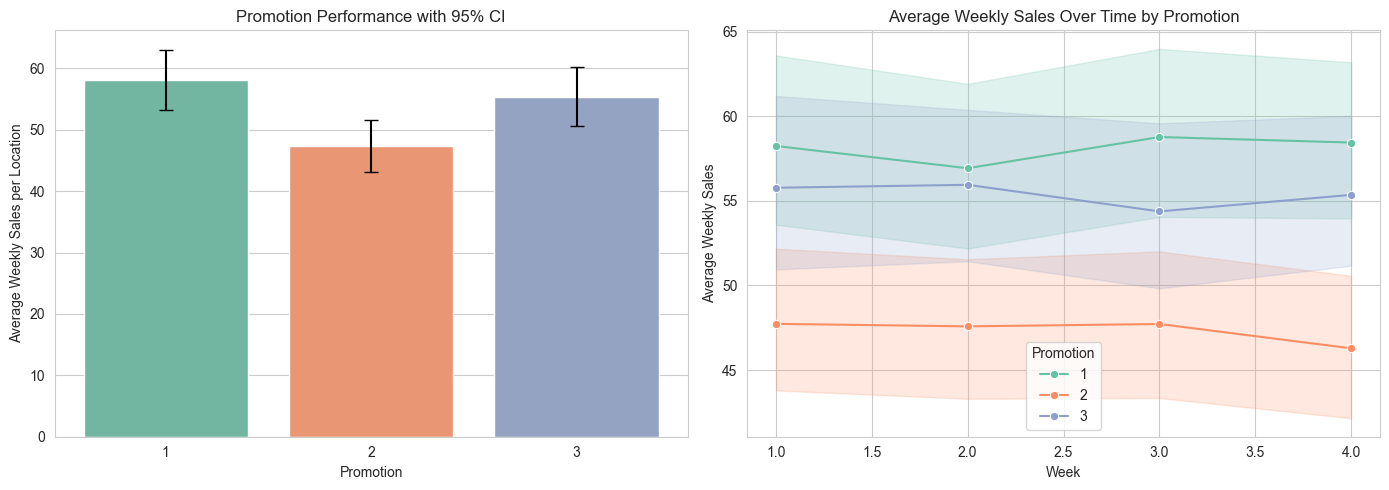

In [28]:
summary_df = avg_sales_promotion[["Promotion", "AvgWeeklySalesMeanPerPromotion", "std", "locationCount"]].copy()
summary_df = summary_df.rename(columns={"AvgWeeklySalesMeanPerPromotion": "mean_sales"})

summary_df["se"] = summary_df["std"] / np.sqrt(summary_df["locationCount"])

ci_low, ci_high = stats.t.interval(
    0.95,
    df=summary_df["locationCount"] - 1,
    loc=summary_df["mean_sales"],
    scale=summary_df["se"]
)
summary_df["ci_lower"] = ci_low
summary_df["ci_upper"] = ci_high

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=summary_df,
    x="Promotion",
    y="mean_sales",
    palette="Set2",
    hue="Promotion",
    legend=False,
    errorbar=None,
    ax=axes[0]
)

axes[0].errorbar(
    x=range(len(summary_df)),
    y=summary_df["mean_sales"],
    yerr=[
        summary_df["mean_sales"] - summary_df["ci_lower"],
        summary_df["ci_upper"] - summary_df["mean_sales"],
    ],
    fmt="none",
    c="black",
    capsize=5,
)

axes[0].set_ylabel("Average Weekly Sales per Location")
axes[0].set_title("Promotion Performance with 95% CI")

sns.lineplot(
    data=marketing_data,
    x="week",
    y="SalesInThousands",
    hue="Promotion",
    errorbar=("ci", 95),
    estimator="mean",
    marker="o",
    palette="Set2",
    ax=axes[1],
)
axes[1].set_title("Average Weekly Sales Over Time by Promotion")
axes[1].set_ylabel("Average Weekly Sales")
axes[1].set_xlabel("Week")
axes[1].grid(True)

plt.tight_layout()
plt.show()

Both visualizations broadly reflect the results from our t-tests.
Promotions 1 and 3 show overlapping confidence intervals in both: the Average Weekly Sales per Location and the examination over time, suggesting no statistically significant difference between them.
Promotion 2, on the other hand, tends to show lower average sales overall. However, the confidence intervals of Promotion 2 and 3 slightly overlap, indicating that this visual evidence alone is less conclusive than the statistical test results.

This brings us to our decision.

## Decision

Promotion 1 statistically significantly outperforms Promotion 2:
- Estimated treatment effect: 10.77
- 95% Confidence Interval: [4.38, 17.16]
- p value: 0.001

Promotion 1 and Promotion 3 perform similarly from a statistical standpoint: 
- Estimated treatment effect: 2.73
- 95% Confidence Interval: [-4.07, 9.53]
- p value: 0.426

Promotion 2 performs statistically significantly worse than Promotion 3:
- Estimated treatment effect: -8.04
- 95% Confidence Interval: [-14.37, -1.7]
- p value: 0.014


While we initially after Calculations assumed that Promotion 3 dominates, we now see: more precisely Promotion 1 and 3 outperform Promotion 2. And Promotion 1 and 3 perform similarly from a statistical standpoint, which means those two are the best strategies to go with. 

**Final Decision:** 

From a statistical standpoint, either `Promotion 1 or Promotion 3` can be chosen as the optimal marketing strategy.